In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
folder_path = "C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data"
data = {}
for file in os.listdir(folder_path):
    # print(file.split(".")[0])
    data[file.split(".")[0].replace("olist_","").replace("_dataset","").replace("order_","")] = folder_path + "/" + file
data

{'customers': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_customers_dataset.csv',
 'geolocation': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_geolocation_dataset.csv',
 'orders': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_orders_dataset.csv',
 'items': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_items_dataset.csv',
 'payments': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_payments_dataset.csv',
 'reviews': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_reviews_dataset.csv',
 'products': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_products_dataset.csv',
 'sellers': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_sellers_dataset.csv',
 'product_category_name_translation': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/product_category_name_transla

In [ ]:
Analyze relationships between numerical variables.

Heatmap:
sns.heatmap(corr, annot=True)
plt.show()

76. Which numerical variables are correlated?

77. Is freight value related to product price?

78. Is delivery time related to review score?

79. Is payment value related to installments?

In [ ]:
77. Is freight value related to product price?
I used the Pearson correlation coefficient to analyze the relationship between product price and freight value. 
    The correlation was approximately 0.414, indicating a moderate positive relationship.
        This suggests that higher-priced products tend to be associated with higher freight values,
although there are other factors that may affect shipping costs.

I used a scatterplot to visualize the relationship between product price and freight value, 
and a heatmap to examine correlations among multiple numerical variables.”

In [4]:
df_items = pd.read_csv(data["items"])
df_items["price"].corr(df_items["freight_value"])

np.float64(0.41420431036303473)

In [5]:
correlation = df_items[["price", "freight_value"]].corr()

In [6]:
correlation

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


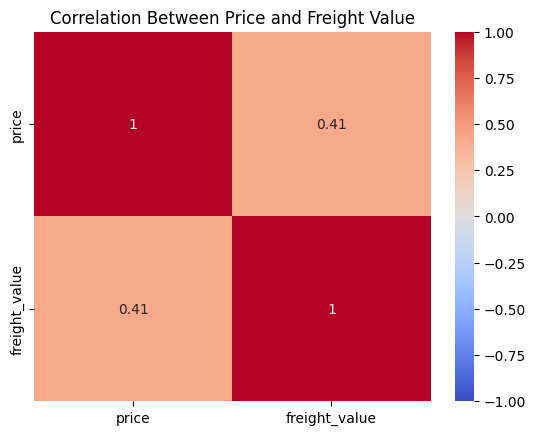

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Price and Freight Value")
plt.show()


#annot=True — displays the correlation values inside the cells.

#cmap="coolwarm" — uses colors to distinguish negative and positive correlations.

#vmin=-1, vmax=1 — sets the correlation scale from −1 to +1.

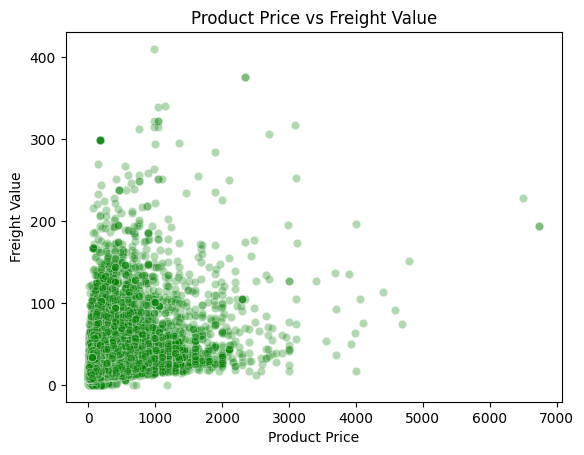

In [13]:
sns.scatterplot(data=df_items, x="price", y="freight_value",alpha=0.3,color="green")

plt.title("Product Price vs Freight Value")
plt.xlabel("Product Price")
plt.ylabel("Freight Value")
plt.show()

In [ ]:
78. Is delivery time related to review score?
I calculated the delivery time for each order and analyzed its relationship with the review score using Pearson correlation. 
    The correlation coefficient was approximately -0.334, indicating a moderate negative relationship. 
    This suggests that orders with longer delivery times tend to receive lower review scores, 
    although other factors may also influence customer satisfaction.”

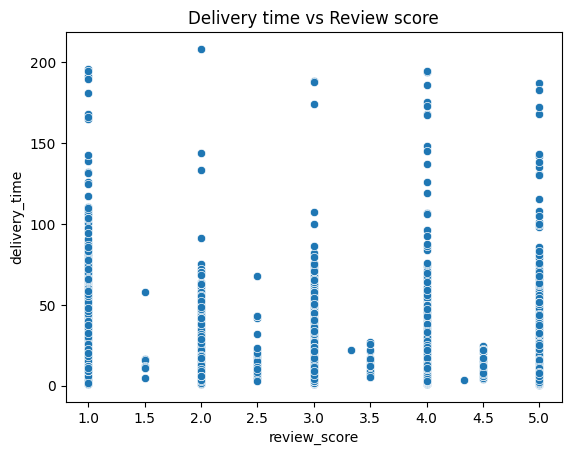

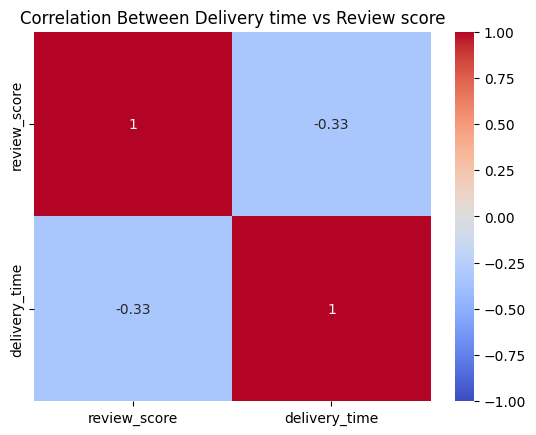

,review_score,delivery_time
review_score,1.000000,-0.334302
delivery_time,-0.334302,1.000000


In [69]:
df_reviews = pd.read_csv(data["reviews"])
df_orders = pd.read_csv(data["orders"])

df_orders["delivery_time"] = (pd.to_datetime(df_orders["order_delivered_customer_date"]) - pd.to_datetime(df_orders["order_purchase_timestamp"])).dt.total_seconds()/(24*60*60)
df_reviews.columns
reviews_grouped = df_reviews.groupby("order_id")["review_score"].mean()
orders_reviews = pd.merge(df_orders,reviews_grouped,on="order_id",how="inner")
# removing orders for do not having delivery dates
orders_reviews = orders_reviews.dropna(
    subset=["delivery_time", "review_score"]
)
# correlation
correlation = orders_reviews[["review_score", "delivery_time"]].corr()
# print("correlation between review_score and delivery_time is:",correlation)

# scatterplot
sns.scatterplot(data = orders_reviews,x="review_score",y="delivery_time")
plt.title("Delivery time vs Review score")
plt.xlabel("review_score")
plt.ylabel("delivery_time")
plt.show()
# heatmap
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Delivery time vs Review score")
plt.show()
correlation

In [47]:
orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.436574,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13.782037,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9.394213,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13.208750,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2.873877,5.0


In [ ]:
79. Is payment value related to installments?
I calculated the Pearson correlation between payment value and the number of installments using Pandas. 
    The correlation was approximately 0.33, indicating a weak-to-moderate positive linear relationship. 
        This suggests that higher payment amounts tend to be associated with more installments, but correlation does not imply causation.

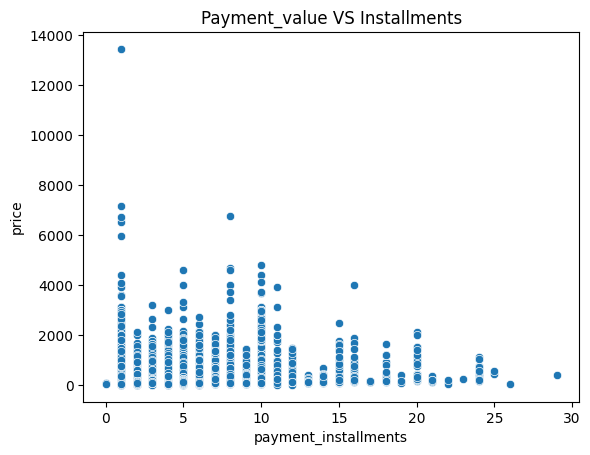

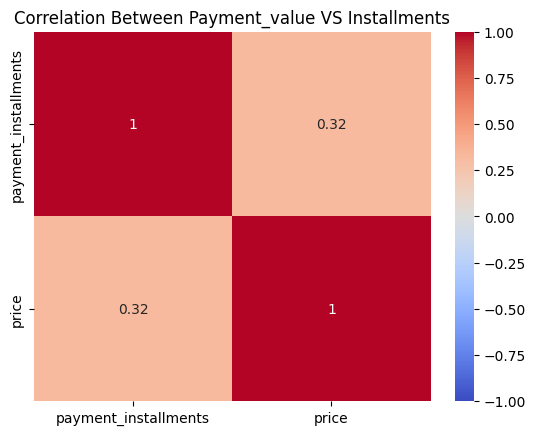

,payment_installments,price
payment_installments,1.000000,0.316089
price,0.316089,1.000000


In [68]:
df_payments = pd.read_csv(data["payments"])
df_items = pd.read_csv(data["items"])
df_items_grouped = df_items.groupby("order_id")["price"].sum()
df_payments_grouped = df_payments.groupby("order_id")["payment_installments"].sum()
payments_items = pd.merge(df_payments_grouped,df_items_grouped,on="order_id",how="inner")
correlation = payments_items[["payment_installments","price"]].corr()

#print("correlation between payment_value and installments is:",correlation)

# scatterplot
sns.scatterplot(data = payments_items,x="payment_installments",y="price")
plt.title("Payment_value VS Installments")
plt.xlabel("payment_installments")
plt.ylabel("price")
plt.show()
# heatmap
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Payment_value VS Installments")
plt.show()
correlation


In [48]:
df_payments = pd.read_csv(data["payments"])
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


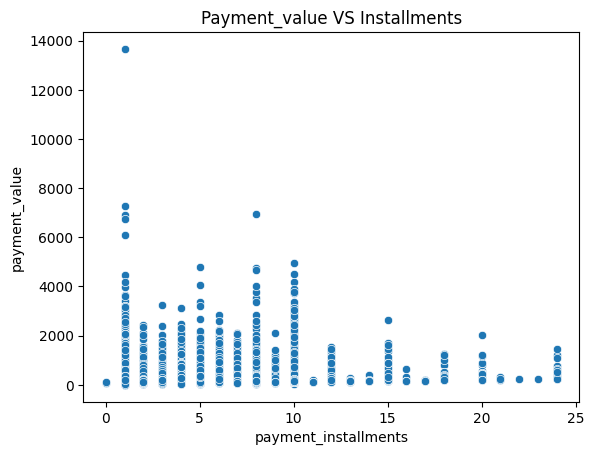

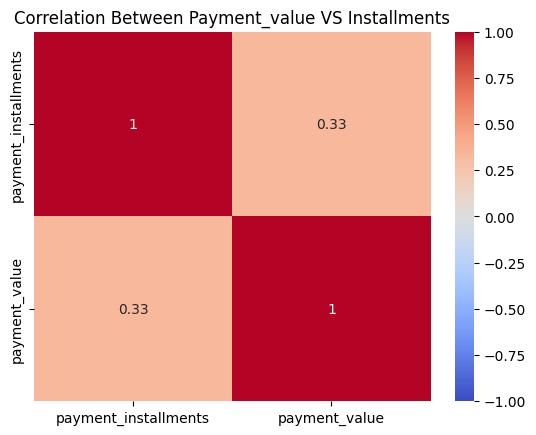

,payment_installments,payment_value
payment_installments,1.000000,0.330811
payment_value,0.330811,1.000000


In [71]:
correlation=df_payments[["payment_installments","payment_value"]].corr()
correlation
sns.scatterplot(data = df_payments,x="payment_installments",y="payment_value")
plt.title("Payment_value VS Installments")
plt.xlabel("payment_installments")
plt.ylabel("payment_value")
plt.show()
# heatmap
sns.heatmap(correlation, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Payment_value VS Installments")
plt.show()
correlation


In [ ]:
76. Which numerical variables are correlated?
I used Pandas to select numerical columns and calculate their correlation matrix. 
    Then I visualized the results using a heatmap.
    I found a moderate positive correlation of approximately 0.41 between product price and freight value.
    The correlations involving order item ID were close to zero, indicating little linear relationship.

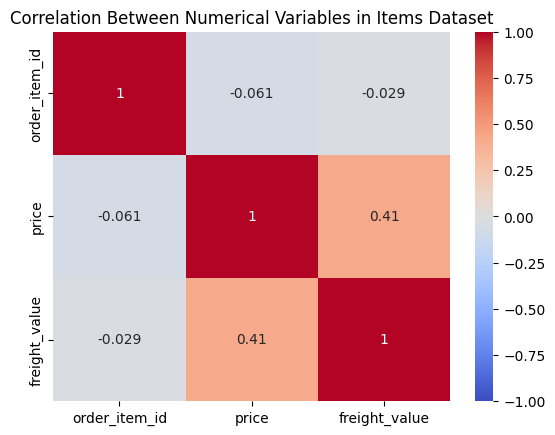

,order_item_id,price,freight_value
order_item_id,1.000000,-0.060522,-0.029380
price,-0.060522,1.000000,0.414204
freight_value,-0.029380,0.414204,1.000000


In [74]:
df_items = pd.read_csv(data["items"])
numerical_data = df_items.select_dtypes(include="number")
correlation = numerical_data.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Numerical Variables in Items Dataset")
plt.show()
correlation


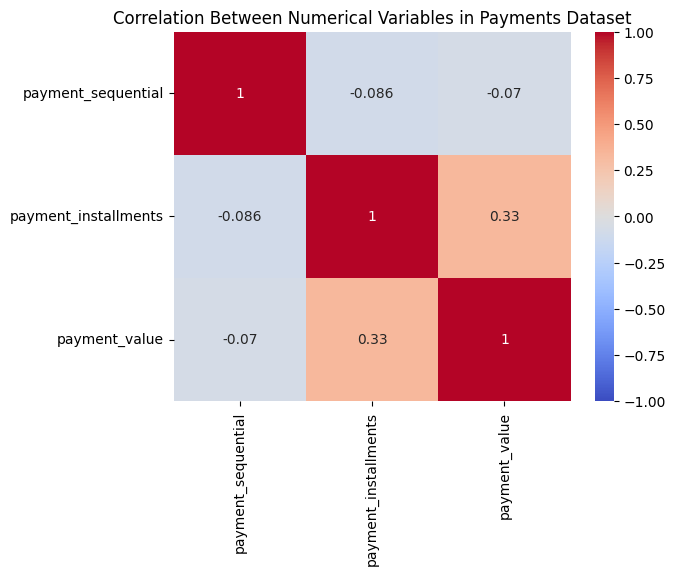

,payment_sequential,payment_installments,payment_value
payment_sequential,1.000000,-0.086363,-0.069593
payment_installments,-0.086363,1.000000,0.330811
payment_value,-0.069593,0.330811,1.000000


In [76]:
df_payments = pd.read_csv(data["payments"])
numerical_data = df_payments.select_dtypes(include="number")
correlation = numerical_data.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Numerical Variables in Payments Dataset")
plt.show()

correlation
